In [1]:
import pandas as pd 
import numpy as np

In [2]:
df = pd.read_csv("thyroid.data", header=None, sep="|")[0]
df = df.str.split(",", expand=True)

cols = [
    "age","sex","on_thyroxine","query_on_thyroxine","on_antithyroid_medication",
    "sick","pregnant","thyroid_surgery","I131_treatment","query_hypothyroid",
    "query_hyperthyroid","lithium","goitre","tumor","hypopituitary", "psych",
    "TSH_measured","TSH","T3_measured","T3",
    "TT4_measured","TT4","T4U_measured","T4U",
    "FTI_measured","FTI","TBG_measured","TBG",
    "referral_source","class"
]
df.columns = cols

df = df.replace("?", np.nan)

/tmp/ipykernel_145268/3074522904.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("?", np.nan)


In [3]:
df.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,class
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,NaN,SVHC,negative.
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,NaN,f,NaN,f,NaN,other,negative.
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,NaN,other,negative.
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,NaN,f,NaN,f,NaN,other,negative.
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,NaN,SVI,negative.


In [4]:
# drop referral_source as it is not a medical feature
df = df.drop(columns=["referral_source"])

In [5]:
# show cols with non-zero nans
print("Missing values per column:")
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0])

Missing values per column:
age       1
sex     150
TSH     369
T3      769
TT4     231
T4U     387
FTI     385
TBG    3772
dtype: int64


In [6]:
# we can see that TSH, T3, TT4, T4U, BTI, TBG are all "?" only when their corresponding measured column is f (i.e. not measured)

print("TSH_measured: ", df[df["TSH_measured"] == "f"]["TSH"].unique())
print("T3_measured: ", df[df["T3_measured"] == "f"]["T3"].unique())
print("TT4_measured: ", df[df["TT4_measured"] == "f"]["TT4"].unique())
print("T4U_measured: ", df[df["T4U_measured"] == "f"]["T4U"].unique())
print("FTI_measured: ", df[df["FTI_measured"] == "f"]["FTI"].unique())
print("TBG_measured: ", df[df["TBG_measured"] == "f"]["TBG"].unique())

TSH_measured:  [nan]
T3_measured:  [nan]
TT4_measured:  [nan]
T4U_measured:  [nan]
FTI_measured:  [nan]
TBG_measured:  [nan]


In [7]:
from sklearn.impute import KNNImputer

# If we have X_measured as a column, then we can safely impute the corresponding X column with 0 (since it is not measured, it is effectively 0) instead of mean/median imputation which would introduce noise
for col in ["TSH", "T3", "TT4", "T4U", "FTI", "TBG"]:
    measured_col = col + "_measured"
    df[col] = df.apply(lambda row: 0 if row[measured_col] == "f" else row[col], axis=1)

# we will do median imputation for age and majority imputation for sex
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

# we can also use KNN imputation to deal with sex and age nans since they are not related to any measured column

In [8]:
# do one hot encoding for categorical columns
binary_cols = [
    "sex","on_thyroxine","query_on_thyroxine","on_antithyroid_medication",
    "sick","pregnant","thyroid_surgery","I131_treatment","query_hypothyroid",
    "query_hyperthyroid","lithium","goitre","tumor","hypopituitary", "psych",
    "TSH_measured","T3_measured", "TT4_measured",
    "T4U_measured","FTI_measured","TBG_measured",
]

df = pd.get_dummies(df, columns=binary_cols, drop_first=True, dtype=int)

# set class to 1 if class is "sick" else 0
df["class"] = (df["class"]=="sick.").astype(int)

In [9]:
df.head()

,age,TSH,T3,TT4,T4U,FTI,TBG,class,sex_M,on_thyroxine_t,...,lithium_t,goitre_t,tumor_t,hypopituitary_t,psych_t,TSH_measured_t,T3_measured_t,TT4_measured_t,T4U_measured_t,FTI_measured_t
0,41.0,1.3,2.5,125,1.14,109,0,0,0,0,...,0,0,0,0,0,1,1,1,1,1
1,23.0,4.1,2,102,0,0,0,0,0,0,...,0,0,0,0,0,1,1,1,0,0
2,46.0,0.98,0,109,0.91,120,0,0,1,0,...,0,0,0,0,0,1,0,1,1,1
3,70.0,0.16,1.9,175,0,0,0,0,0,1,...,0,0,0,0,0,1,1,1,0,0
4,70.0,0.72,1.2,61,0.87,70,0,0,0,0,...,0,0,0,0,0,1,1,1,1,1


In [10]:
# count nans
print("Missing values per column:")
nan_counts = df.isna().sum()
print(nan_counts[nan_counts > 0])

print("\nClass distribution:")
print(df["class"].value_counts())

Missing values per column:
Series([], dtype: int64)

Class distribution:
class
0    3541
1     231
Name: count, dtype: int64


## Task B

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

X = df.drop(columns=["class"])
y = df["class"]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([("scaler", StandardScaler()), ("logreg", LogisticRegression(max_iter=1000))])

y_pred = cross_val_predict(model, X, y, cv=skf)

In [12]:
print("Accuracy: ", accuracy_score(y, y_pred))
print("Precision: ", precision_score(y, y_pred))
print("Recall: ", recall_score(y, y_pred))
print("F1 Score: ", f1_score(y, y_pred))

# print cross validaty_pred_inved confusion matrices
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

Accuracy:  0.9620890774125133
Precision:  0.7784810126582279
Recall:  0.5324675324675324
F1 Score:  0.6323907455012854
Confusion Matrix:
[[3506   35]
 [ 108  123]]


We can see that are 108 FNs and 35 FPs in the baseline confusion matrix, meaning 108 sick patients were missed out of 231 by the classifier.
Also, observe that even though we only get 53% of the sick patients correctly, our accuracy is 96%, demonstrating how bad of a metric it is in such situations.

## Task C

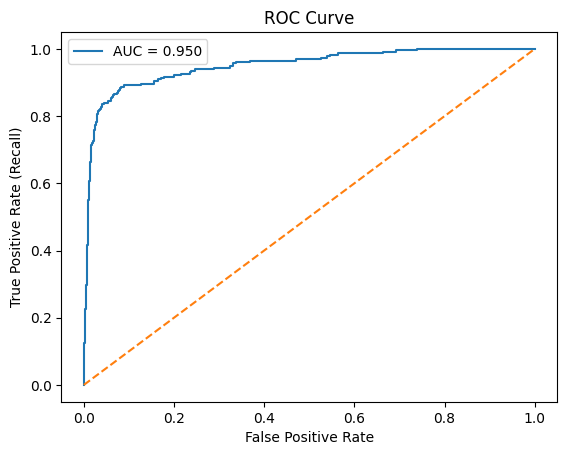

AUC: 0.9496461365989748


In [13]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# cross-validated probabilities for positive class
y_scores = cross_val_predict(model, X, y, cv=skf, method="predict_proba")[:, 1]

fpr, tpr, thresholds = roc_curve(y, y_scores)
auc = roc_auc_score(y, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", auc)

As you can see, the model has a very high AUC, but still has a very bad recall

## Task D

In [14]:
thresholds = np.linspace(0, 1, 1001)
costs = []

C_FN = 10
C_FP = 1

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    cm = confusion_matrix(y, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    cost = C_FN * fn + C_FP * fp
    costs.append(cost)

tau_cost = thresholds[np.argmin(costs)]
print("tau cost: ", tau_cost)

target_recall = 0.90
tau_recall = []

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    if recall_score(y, y_pred_t) >= target_recall:
        tau_recall.append(t)

print("tau recall: ", tau_recall[-1])

youden_scores = []

for t in thresholds:
    y_pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_pred_t).ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    
    youden_scores.append(sensitivity + specificity - 1)

tau_youden = thresholds[np.argmax(youden_scores)]
print("tau youden: ", tau_youden)

tau cost:  0.187
tau recall:  0.043000000000000003
tau youden:  0.10300000000000001


In [15]:
# get the confusion matrix at these thresholds
for name, tau in [("baseline", 0.5), ("cost", tau_cost), ("recall", tau_recall[-1]), ("youden", tau_youden)]:
    y_pred_tau = (y_scores >= tau).astype(int)
    cm = confusion_matrix(y, y_pred_tau)
    print(f"At tau {name} ({tau:.3f}):")
    print("Precision: ", precision_score(y, y_pred_tau))
    print("Recall: ", recall_score(y, y_pred_tau))
    # print("F1 Score: ", f1_score(y, y_pred_tau))
    print("Confusion Matrix:")
    print(cm)
    print()

At tau baseline (0.500):
Precision:  0.7784810126582279
Recall:  0.5324675324675324
Confusion Matrix:
[[3506   35]
 [ 108  123]]

At tau cost (0.187):
Precision:  0.5693215339233039
Recall:  0.8354978354978355
Confusion Matrix:
[[3395  146]
 [  38  193]]

At tau recall (0.043):
Precision:  0.27463863337713534
Recall:  0.9047619047619048
Confusion Matrix:
[[2989  552]
 [  22  209]]

At tau youden (0.103):
Precision:  0.41164658634538154
Recall:  0.8874458874458875
Confusion Matrix:
[[3248  293]
 [  26  205]]



All of these thresholds are much better than 0.5 for recall
Also note that as recall improves, precision becomes bad

## Task E

In [16]:
# inverse frequency weighting
model_inv_freq_weights = Pipeline(
    [("scaler", StandardScaler()), 
    ("logreg", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
y_pred_inv_freq = cross_val_predict(model_inv_freq_weights, X, y, cv=skf)


# weight sensitive logistic regression
C_POS = 10
C_NEG = 1

model_weighted = Pipeline(
    [("scaler", StandardScaler()), 
     ("logreg", LogisticRegression(max_iter=1000, class_weight={0: C_NEG, 1: C_POS}))
])
y_pred_cost = cross_val_predict(model_weighted, X, y, cv=skf)

In [17]:
print("Inverse Frequency model metrics:")
print("Accuracy: ", accuracy_score(y, y_pred_inv_freq))
print("Precision: ", precision_score(y, y_pred_inv_freq))
print("Recall: ", recall_score(y, y_pred_inv_freq)) 
print("F1 Score: ", f1_score(y, y_pred_inv_freq))
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_inv_freq))

print()

print("Cost-Sensitive model metrics:")
print("Accuracy: ", accuracy_score(y, y_pred_cost))
print("Precision: ", precision_score(y, y_pred_cost))
print("Recall: ", recall_score(y, y_pred_cost))
print("F1 Score: ", f1_score(y, y_pred_cost))       
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_cost))

Inverse Frequency model metrics:
Accuracy:  0.8950159066808059
Precision:  0.35751295336787564
Recall:  0.8961038961038961
F1 Score:  0.5111111111111111
Confusion Matrix:
[[3169  372]
 [  24  207]]

Cost-Sensitive model metrics:
Accuracy:  0.9180805938494168
Precision:  0.4194214876033058
Recall:  0.8787878787878788
F1 Score:  0.5678321678321678
Confusion Matrix:
[[3260  281]
 [  28  203]]


## Task F

In [18]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

model_undersampler = ImbPipeline([
    ("undersample", RandomUnderSampler(random_state=42)),
    ("logreg", LogisticRegression(max_iter=10000))
])
y_pred_under = cross_val_predict(model_undersampler, X, y, cv=skf)


model_oversampler = ImbPipeline([
    ("oversample", RandomOverSampler(random_state=42)),
    ("logreg", LogisticRegression(max_iter=10000))
])
y_pred_over = cross_val_predict(model_oversampler, X, y, cv=skf)


smote_pipeline = ImbPipeline([
    ("smote", SMOTE(k_neighbors=5, random_state=42)),
    ("logreg", LogisticRegression(max_iter=10000))
])
y_pred_smote = cross_val_predict(smote_pipeline, X, y, cv=skf)

In [19]:
print("Model with Undersampling metrics:")
print("Accuracy: ", accuracy_score(y, y_pred_under))
print("Precision: ", precision_score(y, y_pred_under))
print("Recall: ", recall_score(y, y_pred_under)) 
print("F1 Score: ", f1_score(y, y_pred_under))
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_under))

print()

print("Model with Oversampling metrics:")
print("Accuracy: ", accuracy_score(y, y_pred_over))
print("Precision: ", precision_score(y, y_pred_over))
print("Recall: ", recall_score(y, y_pred_over))
print("F1 Score: ", f1_score(y, y_pred_over))       
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_over))

print()

print("Model with SMOTE metrics:")
print("Accuracy: ", accuracy_score(y, y_pred_smote))
print("Precision: ", precision_score(y, y_pred_smote))
print("Recall: ", recall_score(y, y_pred_smote))
print("F1 Score: ", f1_score(y, y_pred_smote))       
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred_smote))

Model with Undersampling metrics:
Accuracy:  0.8852067868504772
Precision:  0.33762057877813506
Recall:  0.9090909090909091
F1 Score:  0.492379835873388
Confusion Matrix:
[[3129  412]
 [  21  210]]

Model with Oversampling metrics:
Accuracy:  0.8950159066808059
Precision:  0.3584905660377358
Recall:  0.9047619047619048
F1 Score:  0.5135135135135135
Confusion Matrix:
[[3167  374]
 [  22  209]]

Model with SMOTE metrics:
Accuracy:  0.8907741251325557
Precision:  0.3403880070546737
Recall:  0.8354978354978355
F1 Score:  0.48370927318295737
Confusion Matrix:
[[3167  374]
 [  38  193]]


NOTE:
While I have used imblearn here, you are expected to try to implement these techniques from scratch for practice. You can use the results here to judge if your answers are reasonable